# Single Bit Delta Sigma DAC Example

## Block Diagram

<img src="blockDiagram.png" alt="Block Diagram" width="400"/>

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Signal Defs

In [17]:
# Max input value
max_input_value = 127

# Min input value
min_input_value = -128

# Supply Rail Voltage
supply_voltage = 5.0

# Number of total samples (or number of clock cycles)
number_of_samples = 1000

# Number of samples that the input signal will be constant for
hold_ratio = 100

# Input Signal -> random numbers, should be number_of_samples/hold_ratio long
input_signal = np.random.randint(min_input_value, max_input_value, number_of_samples // hold_ratio)

# Apply zero-order hold to the input signal
input_signal = np.repeat(input_signal, hold_ratio)

# Input to the accumulator
accumulator_input = np.zeros(number_of_samples)

# Output of the accumulator
accumulator_output = np.zeros(number_of_samples)

# MSB output
msb_output = np.zeros(number_of_samples)

# PDM Output
pdm_output = np.zeros(number_of_samples)

# Feedback signal to the first summing junction
feedback_signal = np.zeros(number_of_samples)

## DAC Logic

In [18]:
for idx in range(number_of_samples):
    # Do the initial summing junction
    accumulator_input[idx] = input_signal[idx] - feedback_signal[idx]
    
    # Do the accumulator
    accumulator_output[idx] = accumulator_output[idx-1] + accumulator_input[idx]
    
    # Do the MSB operation (threshold based off of sign bit)
    msb_output[idx] =  not np.signbit(accumulator_output[idx])
    
    # Do the 1 bit digital to digital converter
    temp = idx+1 if idx+1 < number_of_samples else 0
    feedback_signal[temp] = max_input_value if msb_output[idx] else min_input_value
    
    # Generate the output
    pdm_output[idx] = supply_voltage if msb_output[idx] else 0
    
# Smooth the output using the hold ratio
pdm_avg_output = np.convolve(pdm_output, np.ones(hold_ratio)/hold_ratio, mode='same') 

## Plotting

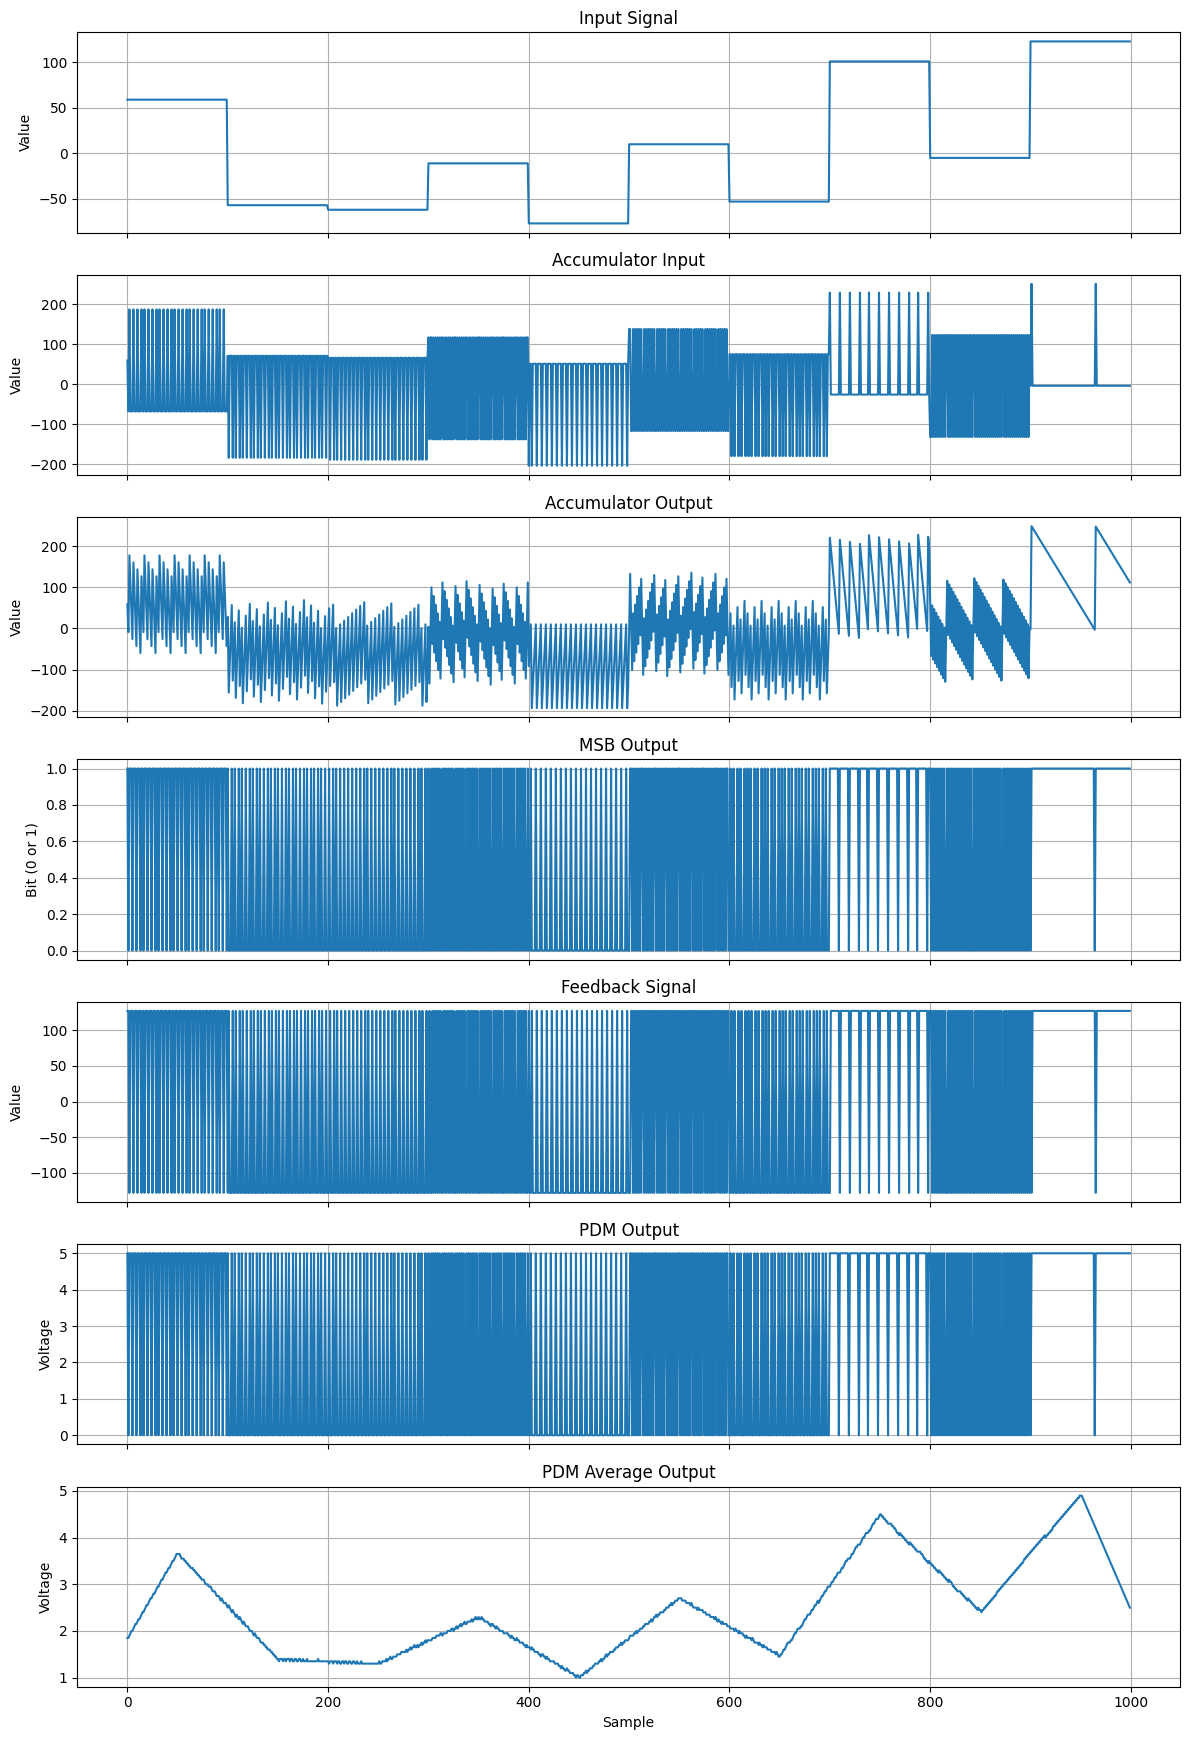

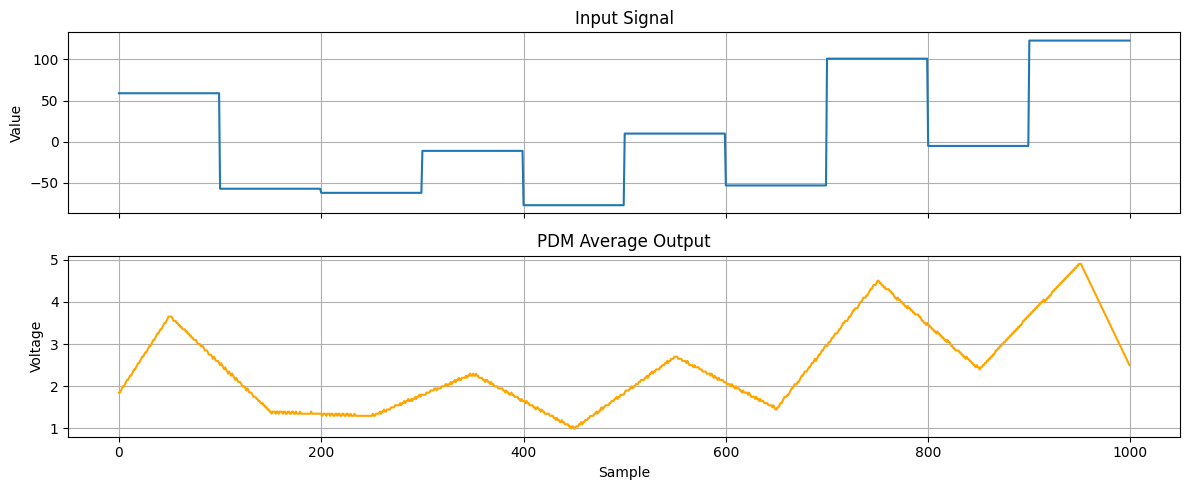

In [19]:
# ...existing code...

# First: plot all signals as before
import matplotlib.pyplot as plt

signals = [
    (input_signal, "Input Signal", "Sample", "Value"),
    (accumulator_input, "Accumulator Input", "Sample", "Value"),
    (accumulator_output, "Accumulator Output", "Sample", "Value"),
    (msb_output, "MSB Output", "Sample", "Bit (0 or 1)"),
    (feedback_signal, "Feedback Signal", "Sample", "Value"),
    (pdm_output, "PDM Output", "Sample", "Voltage"),
    (pdm_avg_output, "PDM Average Output", "Sample", "Voltage"),
]

num_signals = len(signals)
fig, axes = plt.subplots(num_signals, 1, figsize=(12, 2.5 * num_signals), sharex=True)

for ax, (signal, title, xlabel, ylabel) in zip(axes, signals):
    ax.plot(signal)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True)

axes[-1].set_xlabel("Sample")
plt.tight_layout()
plt.show()

# Second: plot only input signal and averaged output
fig2, ax2 = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax2[0].plot(input_signal, label="Input Signal")
ax2[0].set_title("Input Signal")
ax2[0].set_ylabel("Value")
ax2[0].grid(True)

ax2[1].plot(pdm_avg_output, label="PDM Average Output", color='orange')
ax2[1].set_title("PDM Average Output")
ax2[1].set_ylabel("Voltage")
ax2[1].set_xlabel("Sample")
ax2[1].grid(True)

plt.tight_layout()
plt.show()
# ...existing code...